# Random Forest Model  

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report,mean_squared_error,root_mean_squared_error,r2_score,mean_absolute_error

import warnings
warnings.filterwarnings("ignore")


In [15]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Data Encoding 

In [16]:
# ...existing code...
from sklearn.preprocessing import LabelEncoder

# Encode all object and category columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = le.fit_transform(df[col])

df.head()
# ...existing code...

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


# Classification Example

0.6530612244897959
              precision    recall  f1-score   support

           0       0.58      0.37      0.45        19
           1       0.68      0.83      0.75        30

    accuracy                           0.65        49
   macro avg       0.63      0.60      0.60        49
weighted avg       0.64      0.65      0.63        49



<Axes: >

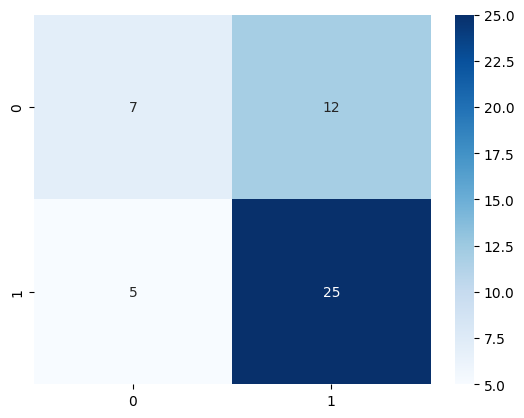

In [32]:
X = df.drop('sex', axis=1)
y = df['sex']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)

model = RandomForestClassifier(n_estimators=50,criterion='entropy',max_depth=6,random_state=42)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

# evaluate the model 
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test,y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d',cmap='Blues')

# Regression Example 

In [47]:
# Create feature set and target variable 
X = df.drop('tip',axis=1)
y = df['tip']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit the model
model = RandomForestRegressor(n_estimators=200,max_depth=5,criterion='friedman_mse',random_state=42)
model.fit(X_train,y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))
print("Root Mean Squared Error:", root_mean_squared_error(y_test, y_pred))

Mean Squared Error: 0.8939061745720484
Mean Absolute Error: 0.7487063922724616
R-squared: 0.28485866659850867
Root Mean Squared Error: 0.945466114978241


# Visualize Feature Importance 

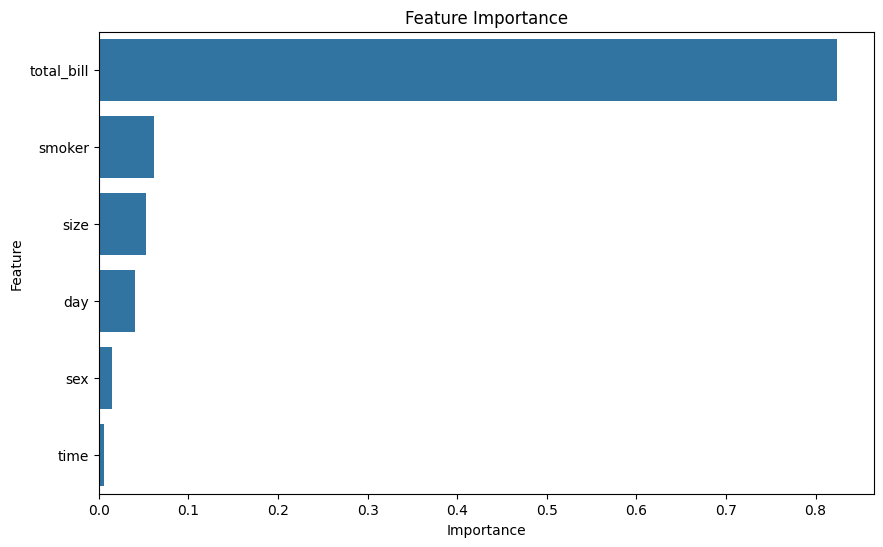

In [48]:
# Visualize feature importance
feature_importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()